# Empirical Finance - 20999

# Lab 3: Estimation of the Log Random Walk model

In this lab, we analyze the performance of the estimators for the expected value and variance of log returns analyzed in Chapter 3 of the Lecture Notes. The log returns are computed from the price series of a security, which is assumed to follow a Log Random Walk model.

We begin by downloading a 10-year time series of adjusted closing prices for the Bank of America Corporation.

In [1]:
from datetime import date
import yfinance as yf

myStart = date(2014, 12 ,31)
myEnd = date(2024, 12, 31)


myTicker = "BAC"

prices = yf.download(myTicker, myStart, myEnd)
prices = prices.droplevel(1, axis=1)
prices = prices.drop(columns=["High", "Low", "Open", "Volume"])
prices = prices.rename(columns={prices.columns[0]: "AP"})

/tmp/ipykernel_14553/2238300429.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(myTicker, myStart, myEnd)
[*********************100%***********************]  1 of 1 completed


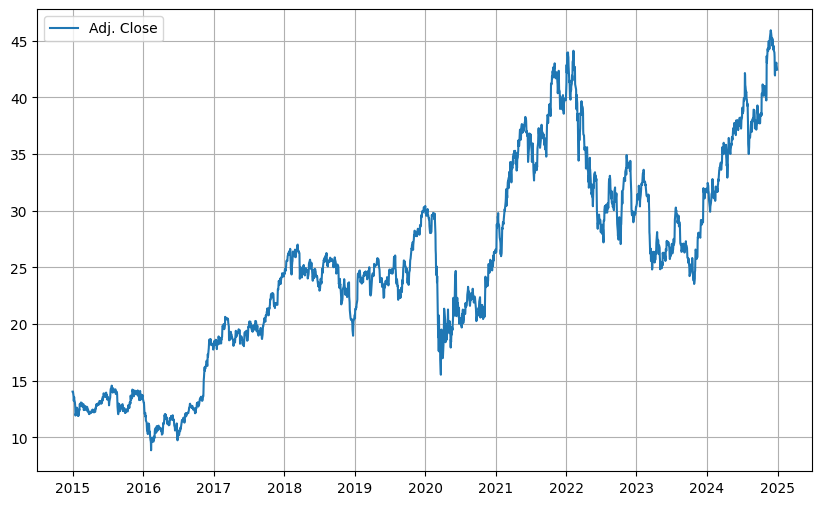

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
plt.plot(prices["AP"], label = "Adj. Close")
plt.grid(True)
plt.legend()

plt.savefig("IBM_AdjClose.jpeg", format="jpeg")
plt.savefig("IBM_AdjClose.pdf", format="pdf")

plt.show()

By default, the `yf.download()` function downloads prices at a daily frequency.

However, we understood that the opbservation frequency does (not) play a role when estimating the log return sample mean.

Since we are, as always, interested in annual parameters, we resample the daily prices to an annual frequency, taking the last available price for each year.

In [3]:
prices_Y = prices.resample("YE").last()

In [4]:
import numpy as np

r_Y = np.log(prices_Y/prices_Y.shift(1))
r_Y = r_Y.dropna()

The annual expected log return is then estimated by the sample mean of the annual log returns,
$$
\hat{\mu} = \frac{1}{n} \sum_{i=0}^{n-1} r_{t-i}^* .
$$


In [5]:
mean_Y = r_Y.mean().to_numpy()[0]
mean_Y

np.float64(0.11063060090820678)

In order to assess the precision of this estimate, we compute the approximate 95\% confidence interval for the true parameter $\mu$ (see Example 3.3 of the Lecture Notes):
$$
\Pr\!\big[\, \hat{\mu} - 2\,\text{st.e.}[\hat{\mu}] \leq \mu \leq \hat{\mu} + 2\,\text{st.e.}[\hat{\mu}] \,\big] \approx 95\%
$$
where the standard error of the sample mean of log returns is given by
$$
\text{st.e.}[\hat{\mu}] = \frac{\sigma}{\sqrt{n}} \,
$$
(see Proposition 3.2 of the Lecture Notes).

In [6]:
std_Y = r_Y.std().to_numpy()[0]
std_Y

np.float64(0.2505508136569755)

In [7]:
ste_mean_Y = std_Y/np.sqrt(len(r_Y))
ste_mean_Y

np.float64(0.0792311240764464)

In [8]:
lb_Y = mean_Y-2*ste_mean_Y
ub_Y = mean_Y+2*ste_mean_Y

In [9]:
print(f"Annual log return mean = {mean_Y:.6f}, 95% CI: [{lb_Y:.6f}, {ub_Y:.6f}]")

Annual log return mean = 0.110631, 95% CI: [-0.047832, 0.269093]


As expected, although we are using 10 years of (annual) data, the confidence interval for the expected log return is fairly wide and does not allow us to reject the hypothesis $\mu = 0$ at the usual 95\% confidence level (since 0 lies within the interval). In fact, the value of the t-ratio (see Equation (3.27) of the Lecture Notes) is  
$$
\text{t.ratio}[\hat{\mu}] = \frac{\hat{\mu}}{\text{st.e.}[\hat{\mu}]} = \frac{\hat{\mu}}{\sigma} \sqrt{n},
$$  
where the standard deviation in the denominator is replaced by its sample estimate, and this value is smaller than 2.

In [10]:
tratio_Y = mean_Y/std_Y*np.sqrt(len(r_Y))
tratio_Y

np.float64(1.3963023016241)

We now return to the original daily data in the (vain) hope that estimating the expected log return from daily observations will yield a more precise estimate.

In [11]:
r = np.log(prices/prices.shift(1))
r = r.dropna()

mean_D = r.mean().to_numpy()[0]
mean_D

np.float64(0.0004398831050028116)

In [12]:
std_D = r.std().to_numpy()[0]
std_D

np.float64(0.019575066592880518)

In [13]:
n_D = len(r)
n_D

2515

In [14]:
ste_D = std_D/np.sqrt(n_D)
ste_D

np.float64(0.00039033208684167086)

In [15]:
lb_D = mean_D-2*ste_D
ub_D = mean_D+2*ste_D

In [16]:
print(f"Daily log return mean = {mean_D:.6f}, 95% CI: [{lb_D:.6f}, {ub_D:.6f}]")

Daily log return mean = 0.000440, 95% CI: [-0.000341, 0.001221]


As expected, the larger number of data points mechanically reduces the standard error of the (daily) log return sample mean and narrows its confidence interval.  

However, this gain is only apparent: once we annualize the results using the actual number of trading days per year (typically between 250 and 252), we obtain the same point estimate for the annual log return mean and a nearly identical confidence interval as with the annual data.

In [17]:
annFct = n_D/10
annFct

251.5

In [18]:
print(f"{'Method':<35} {'Mean':>12} {'95% CI Lower':>15} {'95% CI Upper':>15}")
print("-" * 80)
print(f"{'Annualized (from daily data)':<35} {mean_D*annFct:12.6f} {lb_D*annFct:15.6f} {ub_D*annFct:15.6f}")
print(f"{'Annual (from yearly data)':<35} {mean_Y:12.6f} {lb_Y:15.6f} {ub_Y:15.6f}")

Method                                      Mean    95% CI Lower    95% CI Upper
--------------------------------------------------------------------------------
Annualized (from daily data)            0.110631       -0.085706        0.306968
Annual (from yearly data)               0.110631       -0.047832        0.269093


Indeed, the $t$-ratio computed for the daily log-return sample mean is comparable to the one obtained above using annual data.

In [19]:
tratio_D = mean_D/std_D*np.sqrt(n_D)
tratio_D

np.float64(1.126945797774601)

We now investigate the stability over time of both the annualized log return sample mean and the sample standard deviation by computing rolling estimates of these two parameters over a fixed window of 250 days (approximately one year).  

Formally, at each point in time we compute  
$$
\hat{\mu}_t = \frac{1}{250} \sum_{i=0}^{249} r_{t-i}^*
$$  
and  
$$
\hat{\sigma}_t = \sqrt{ \frac{1}{249} \sum_{i=0}^{249} \left( r_{t-i}^* - \hat{\mu}_t \right)^2 },
$$  
where, for simplicity, the volatility estimate is based on the unbiased sample variance rather than on the log return sample variance of Definition 3.4 in the Lecture Notes (which does not involve the sample mean).

In [20]:
r_np = r.to_numpy()
r_np

array([[ 0.00055923],
       [-0.02948078],
       [-0.03037608],
       ...,
       [ 0.00382324],
       [-0.00472494],
       [-0.00974514]])

In [21]:
n = len(r_np)

rollWindowLength = 250

mu_hats = np.zeros(n)
sigma_hats = np.zeros(n)

for i in range(n):
  if i < rollWindowLength:
    mu_hats[i] = np.nan
    sigma_hats[i] = np.nan
  else:
    mu_hats[i] = np.mean(r_np[i-rollWindowLength+1:i+1])
    sigma_hats[i] = np.std(r_np[i-rollWindowLength+1:i+1])


For clarity and ease of interpretation, we plot these rolling estimates in annualized terms: $250 \hat{\mu}_t$ and $\sqrt{250}\,\hat{\sigma}_t$.

In [22]:
dates = r.index.to_numpy()

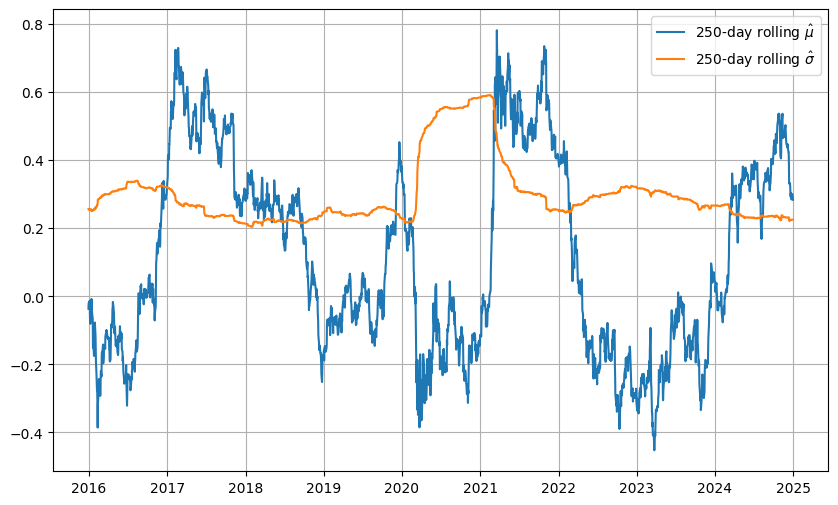

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
plt.plot(dates, mu_hats*250, label = r"250-day rolling $\hat{\mu}$")
plt.plot(dates, sigma_hats*np.sqrt(250), label = r"250-day rolling $\hat{\sigma}$")
plt.grid(True)
plt.legend()
plt.show()

We now turn to the RiskMetrics estimator of the log return variance, defined as  
$$
V_t = \frac{\displaystyle\sum_{i=0}^{n-1} \lambda^i \left( r_{t-i}^* \right)^2}{\displaystyle\sum_{j=0}^{n-1} \lambda^j},
$$  
for $\lambda \in (0,1)$.  

As discussed in class and in the Lecture Notes, the RiskMetrics variance estimator can be seen as astandard sample variance estimator (under the assumption of zero expected log return) with a different set of weights:  
$$
V_t = \sum_{i=0}^{n-1} \underbrace{\frac{\lambda^i}{\sum_{j=0}^{n-1} \lambda^j}}_{w_i} (r_{t-i}^*)^2
     = \sum_{i=0}^{n-1} w_i (r_{t-i}^*)^2.
$$  

We therefore begin our analysis of the RiskMetrics estimator by examining how the set of weights $\{ w_i \}_{i=0}^{n-1}$ behaves for different values of $\lambda \in (0,1)$.

In [24]:
weights94 = 0.94 ** np.arange(rollWindowLength)
weights94 /= weights94.sum()

In [25]:
uniformweights = np.ones(rollWindowLength)/rollWindowLength

weights99 = 0.99 ** np.arange(rollWindowLength)
weights99 /= weights99.sum()
weights90 = 0.90 ** np.arange(rollWindowLength)
weights90 /= weights90.sum()

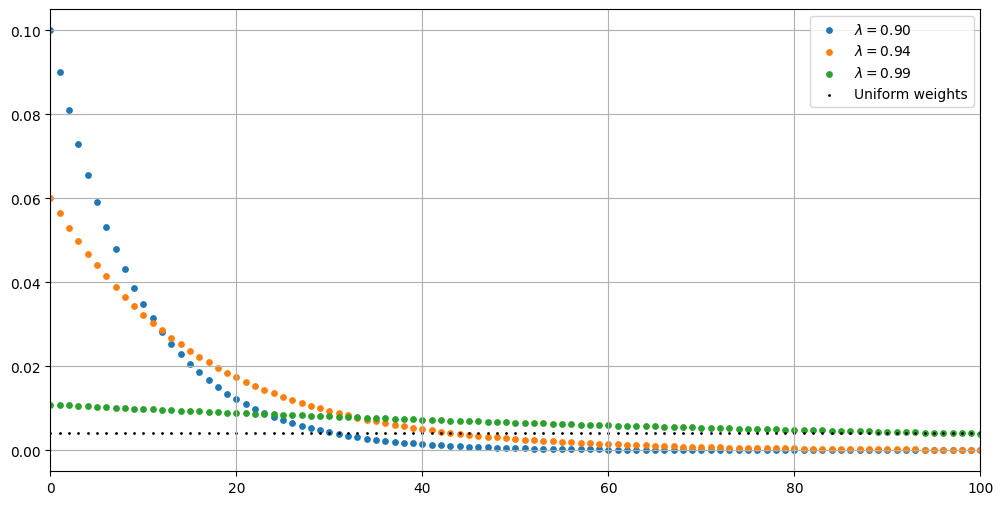

In [26]:
plt.figure(figsize = (12,6))

plt.scatter(np.arange(rollWindowLength), weights90, s = 15, label = r"$\lambda = 0.90$")
plt.scatter(np.arange(rollWindowLength), weights94, s = 15, label = r"$\lambda = 0.94$")
plt.scatter(np.arange(rollWindowLength), weights99, s = 15, label = r"$\lambda = 0.99$")
plt.scatter(np.arange(rollWindowLength), uniformweights, s = 1, label = r"Uniform weights", color = "black")

plt.xlim([0, 100])
plt.grid(True)
plt.legend()
plt.show()

We now compute the rolling RiskMetrics estimates with $\lambda = 0.99$, which provides a reasonable degree of persistence in the estimates. These are obtained both from the explicit formula recalled above and from the recursive representation (see Proposition 3.8 of the Lecture Notes):  
$$
V_t \approx \lambda V_{t-1} + (1-\lambda)(r_t^*)^2,
$$  
where the initial value of $V_t$ required to start the recursion is set equal to the sample variance estimate.

In [27]:
lambda_par = 0.99

weights = lambda_par ** np.arange(rollWindowLength)
weights /= weights.sum()

In [28]:
weights = np.flip(weights)

In [29]:
V_lambda = np.zeros(n)
V_lambda_proxy = np.zeros(n)

In [30]:
for i in range(n):
  if i < rollWindowLength:
    V_lambda[i] = np.nan
    V_lambda_proxy[i] = np.nan
  else:
    V_lambda[i] = np.dot(weights, r_np[i-rollWindowLength+1:i+1]**2)
    if i == rollWindowLength:
      V_lambda_proxy[i] = sigma_hats[i]**2
    else:
      V_lambda_proxy[i] = lambda_par * V_lambda_proxy[i-1] + (1 - lambda_par) * r_np[i]**2

/tmp/ipykernel_14553/1979718418.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_lambda[i] = np.dot(weights, r_np[i-rollWindowLength+1:i+1]**2)
/tmp/ipykernel_14553/1979718418.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_lambda_proxy[i] = lambda_par * V_lambda_proxy[i-1] + (1 - lambda_par) * r_np[i]**2


We can now plot the rolling standard deviation estimates obtained earlier together with the two new RiskMetrics estimates, after proper annualization and square rooting. Recall that the RiskMetrics estimator is an estimator of $\sigma^2$; therefore, to make it comparable with the rolling standard deviation, we take its square root.

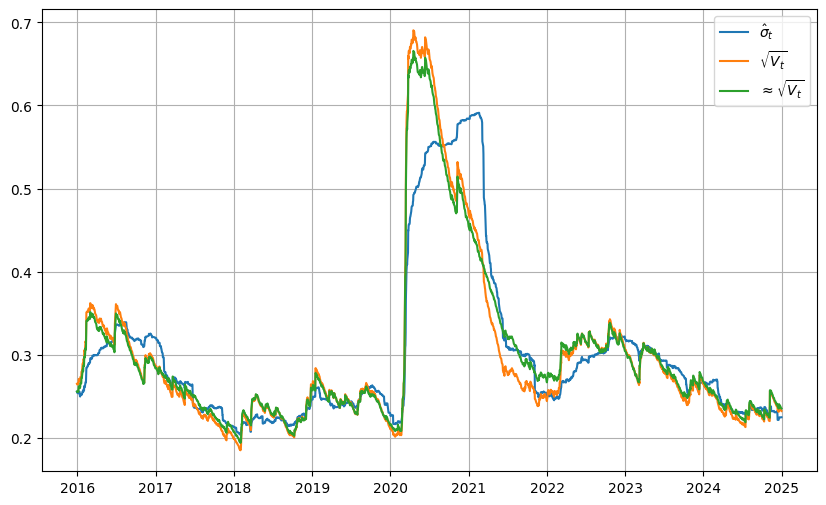

In [31]:
plt.figure(figsize = (10,6))
plt.plot(dates, sigma_hats*np.sqrt(250), label = r"$\hat{\sigma}_t$")
plt.plot(dates, np.sqrt(V_lambda*250), label = r"$\sqrt{V_t}$")
plt.plot(dates, np.sqrt(V_lambda_proxy*250), label = r"$\approx \sqrt{V_t}$")
plt.grid(True)
plt.legend()
plt.show()

Given the explicit expression of the RiskMetrics estimator, we can also visualize the origin of its spikes, which are driven by extreme squared log returns.


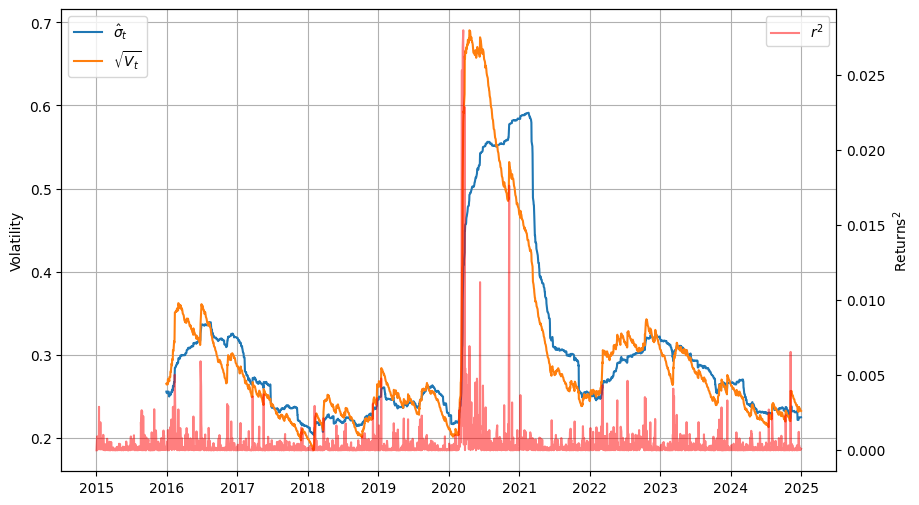

In [32]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(dates, sigma_hats*np.sqrt(250), label=r"$\hat{\sigma}_t$")
ax1.plot(dates, np.sqrt(V_lambda*250), label=r"$\sqrt{V_t}$")
ax1.set_ylabel("Volatility")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(dates, r**2, color="red", label=r"$r^2$", alpha=0.5)
ax2.set_ylabel(r"Returns$^2$")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()

### BONUS: "Manipulation" of expected (log) returns

As discussed in class and in Subsection 3.4.1 of the Lecture Notes, the numerical estimate of the annual log return sample mean depends only on the difference between the log prices at the beginning and at the end of the sample, and on the number of years $n$ in between:  
$$
\hat{\mu}_t = \frac{\ln P_t - \ln P_{t-n}}{n}.
$$  

As reported on page 82 of the Lecture Notes:  

"This also implies that the numerical value of the estimator can be easily manipulated. Even if the length of the time window (i.e., $n$ in the denominator of $\hat{\mu}_t$) is kept nearly unchanged, one could choose an initial observation when the price was temporarily low and a final observation when the price was temporarily high to report a large estimate of the expected log return. Conversely, selecting a nearby initial time when the price was high and a final time when the price was low would yield a much smaller estimated return. Thus, small changes in the starting and ending points of the window can substantially influence the estimate.''  

In what follows, we restrict our analysis to the last year of data, showing how one can compute (and even present, in a somewhat misleading way) a dramatically different expected log return for our security, simply by choosing the timing of the calculation.

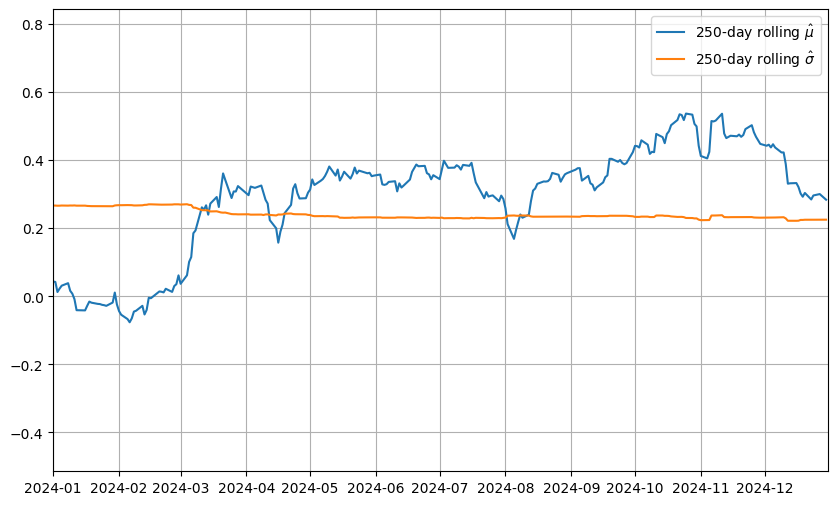

In [33]:
plt.figure(figsize = (10,6))
plt.plot(dates, mu_hats*250, label = r"250-day rolling $\hat{\mu}$")
plt.plot(dates, sigma_hats*np.sqrt(250), label = r"250-day rolling $\hat{\sigma}$")
plt.grid(True)
plt.legend()
plt.xlim([date(2024,1,1), date(2024,12,31)])
plt.show()

In the following, we identify the maximum estimate of the log return mean over the last year of data together with the corresponding date.

In [34]:
highest_mu_hat = np.max(mu_hats[-250:])
highest_mu_hat*250

np.float64(0.5369258090524164)

In [35]:
idx_highest_mu_hat = np.where(mu_hats == highest_mu_hat)[0][0]
idx_highest_mu_hat

np.int64(2470)

We then highlight on the log price series the initial and final points over which this estimate is computed. The estimate corresponds to the slope of the line connecting these two log prices. In the graph, this slope can be computed as the ratio between the change on the $y$-axis, $\ln P_t - \ln P_{t-n}$, and the change on the $x$-axis, $n$, which precisely delivers
$$
\hat{\mu}_t = \frac{\ln P_t - \ln P_{t-n}}{n}.
$$

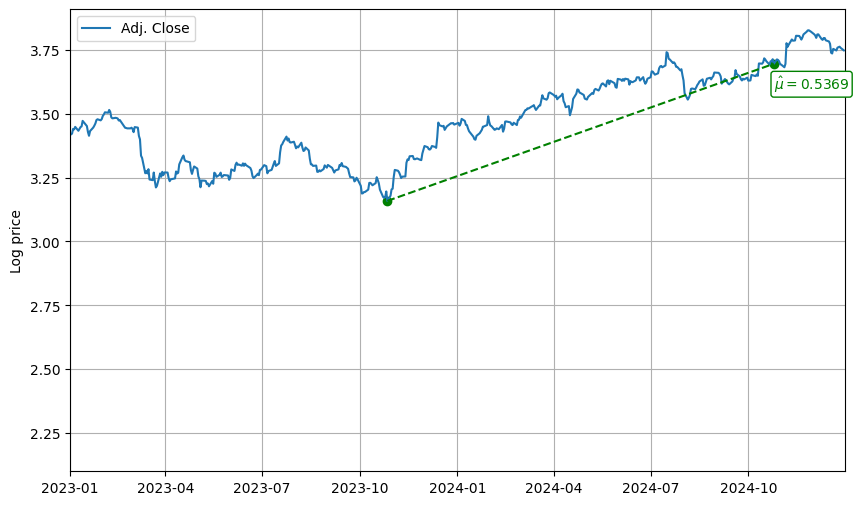

In [36]:
prices_np = prices.iloc[1:].to_numpy()

x_vals_highest = [dates[idx_highest_mu_hat-rollWindowLength], dates[idx_highest_mu_hat]]
y_vals_highest = [prices_np[idx_highest_mu_hat-rollWindowLength], prices_np[idx_highest_mu_hat]]

plt.figure(figsize=(10,6))
plt.plot(np.log(prices["AP"]), label="Adj. Close")

# Dots
plt.scatter(x_vals_highest[0], np.log(y_vals_highest[0]), color="green")
plt.scatter(x_vals_highest[1], np.log(y_vals_highest[1]), color="green")

# Label
plt.text(x_vals_highest[1], np.log(y_vals_highest[1])-0.1, fr"$\hat{{\mu}} = {highest_mu_hat*250:.4f}$", color="green", bbox=dict(facecolor="white", edgecolor="green", boxstyle="round,pad=0.2"))

# Dashed line
plt.plot(x_vals_highest, np.log(y_vals_highest), color="green", linestyle="--")

plt.grid(True)
plt.ylabel("Log price")
plt.legend()
plt.xlim([date(2023,1,1), myEnd])
plt.show()

Finally, we add the same construction for the minimum log return sample mean recorded over the same period.

In [37]:
lowest_mu_hat = np.min(mu_hats[-250:])
lowest_mu_hat*250

np.float64(-0.07630180114754873)

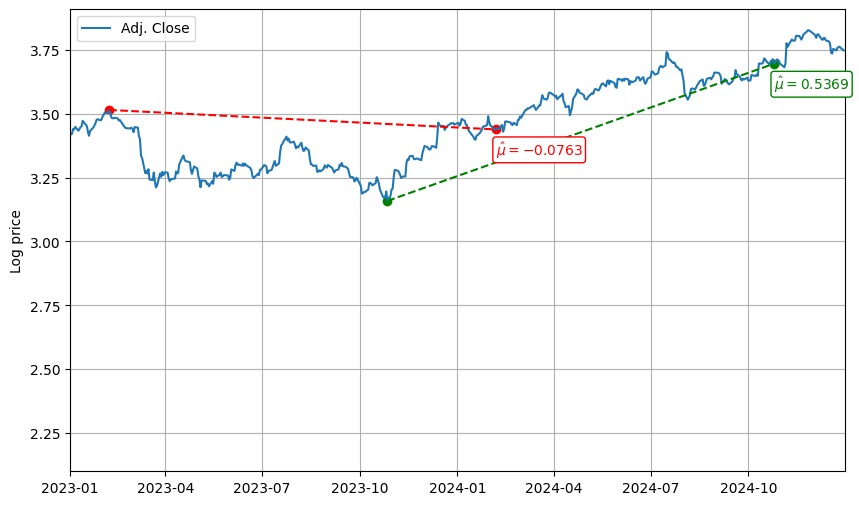

In [38]:
idx_lowest_mu_hat = np.where(mu_hats == lowest_mu_hat)[0][0]

x_vals_lowest = [dates[idx_lowest_mu_hat-rollWindowLength], dates[idx_lowest_mu_hat]]
y_vals_lowest = [prices_np[idx_lowest_mu_hat-rollWindowLength], prices_np[idx_lowest_mu_hat]]

plt.figure(figsize=(10,6))
plt.plot(np.log(prices["AP"]), label="Adj. Close")

# Dots
plt.scatter(x_vals_highest[0], np.log(y_vals_highest[0]), color="green")
plt.scatter(x_vals_highest[1], np.log(y_vals_highest[1]), color="green")
plt.scatter(x_vals_lowest[0], np.log(y_vals_lowest[0]), color="red")
plt.scatter(x_vals_lowest[1], np.log(y_vals_lowest[1]), color="red")

# Label
plt.text(x_vals_highest[1], np.log(y_vals_highest[1])-0.1, fr"$\hat{{\mu}} = {highest_mu_hat*250:.4f}$", color="green", bbox=dict(facecolor="white", edgecolor="green", boxstyle="round,pad=0.2"))
plt.text(x_vals_lowest[1], np.log(y_vals_lowest[1])-0.1, fr"$\hat{{\mu}} = {lowest_mu_hat*250:.4f}$", color="red", bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.2"))

# Dashed line
plt.plot(x_vals_highest, np.log(y_vals_highest), color="green", linestyle="--")
plt.plot(x_vals_lowest, np.log(y_vals_lowest), color="red", linestyle="--")

plt.grid(True)
plt.ylabel("Log price")
plt.legend()
plt.xlim([date(2023,1,1), myEnd])
plt.show()